2025/10/09 12:11:46 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing SVM using PSO...


2025/10/09 12:12:27 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.7789016120094331, Global best: -0.7789016120094331, Runtime: 20.32859 seconds
2025/10/09 12:12:48 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7857241369027651, Global best: -0.7857241369027651, Runtime: 21.61538 seconds
2025/10/09 12:13:49 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7857241369027651, Global best: -0.7857241369027651, Runtime: 60.77261 seconds
2025/10/09 12:15:18 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7857241369027651, Global best: -0.7857241369027651, Runtime: 89.20149 seconds
2025/10/09 12:16:31 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7857241369027651, Global best: -0.7857241369027651, Runtime: 72.78055 seconds
2025/10/09 12:16:31 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: Bas

PSO Accuracy: 0.7857
PSO Best Params: {'C': 2.762, 'gamma': 0.0984, 'kernel': 'rbf'}

Optimizing SVM using GA...


2025/10/09 12:17:14 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.7720747383932588, Global best: -0.7775354917908538, Runtime: 23.95861 seconds
2025/10/09 12:17:31 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.7720747383932588, Global best: -0.7775354917908538, Runtime: 16.95159 seconds
2025/10/09 12:17:51 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.7720747383932588, Global best: -0.7775354917908538, Runtime: 20.40528 seconds
2025/10/09 12:18:17 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.7720747383932588, Global best: -0.7775354917908538, Runtime: 25.90442 seconds
2025/10/09 12:18:49 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.7725301117994517, Global best: -0.7775354917908538, Runtime: 32.17135 seconds
2025/10/09 12:18:49 AM, INFO, mealpy.swarm_based.BA.OriginalBA: O

GA Accuracy: 0.7775
GA Best Params: {'C': 2.099, 'gamma': 0.2579, 'kernel': 'rbf'}

Optimizing SVM using Bat...


2025/10/09 12:19:38 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 1, Current best: -0.7725307330455721, Global best: -0.7725307330455721, Runtime: 24.02116 seconds
2025/10/09 12:20:19 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 2, Current best: -0.7725307330455721, Global best: -0.7725307330455721, Runtime: 40.49087 seconds
2025/10/09 12:20:43 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 3, Current best: -0.7725307330455721, Global best: -0.7725307330455721, Runtime: 24.95344 seconds
2025/10/09 12:21:26 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 4, Current best: -0.7725307330455721, Global best: -0.7725307330455721, Runtime: 42.81709 seconds
2025/10/09 12:22:06 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 5, Current best: -0.7725307330455721, Global best: -0.7725307330455721, Runtime: 40.19884 seconds


Bat Accuracy: 0.7725
Bat Best Params: {'C': 1.082, 'gamma': 0.0034, 'kernel': 'linear'}



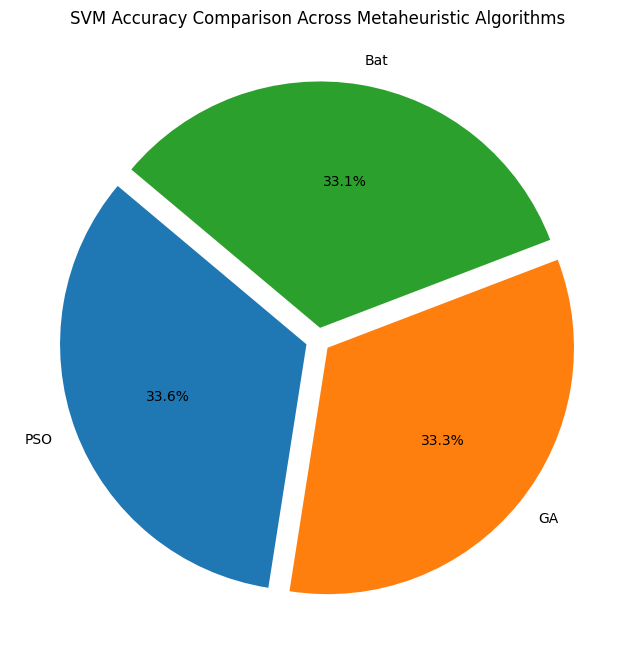

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from mealpy.swarm_based import PSO
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.BA import OriginalBA
import mealpy.swarm_based.BA as bat_algorithm
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# SVM Objective Function
# ----------------------------
def svm_objective_function(solution):
    C = solution[0]
    gamma = solution[1]
    kernel_idx = int(solution[2])
    kernels = ['linear', 'rbf', 'poly']
    kernel = kernels[kernel_idx % len(kernels)]  # ensure valid index
    
    try:
        svm = SVC(C=C, gamma=gamma, kernel=kernel, random_state=42)
        scores = cross_val_score(svm, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # minimize negative accuracy
    except:
        fitness = 1.0
    return fitness

# ----------------------------
# SVM Problem Definition
# ----------------------------
svm_problem = {
    "bounds": [
        FloatVar(lb=0.1, ub=10, name="C"),        # Regularization
        FloatVar(lb=0.0001, ub=1, name="gamma"),  # Kernel coefficient
        FloatVar(lb=0, ub=2, name="kernel")       # 0=linear,1=rbf,2=poly
    ],
    "minmax": "min",
    "obj_func": svm_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": bat_algorithm.OriginalBA(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing SVM using {name}...")
    best_agent = optimizer.solve(svm_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness

    kernel_idx = int(best_solution[2])
    kernels = ['linear', 'rbf', 'poly']
    kernel = kernels[kernel_idx % len(kernels)]

    best_params = {
        'C': round(best_solution[0], 3),
        'gamma': round(best_solution[1], 4),
        'kernel': kernel
    }

    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("SVM Accuracy Comparison Across Metaheuristic Algorithms")
plt.show()
